In [ ]:
# input
cat_ted = "./data/cat-pdbIds-tedRepIds.tsv"
ted_site_domain = "../analysis/site_domain_composition/tmp/repId-tedId-entryId-siteId-siteKind.tsv"
ted_site = "../analysis/site_domain_composition/tmp/entryId-sites-tedIds.tsv"
pred_result = "../../predict_afdb/data/pred_ge_3_clique_3.tsv"

In [2]:
import pandas as pd

df_cat = pd.read_table(cat_ted, header=None, names=["cat", "_", "ted_rep_ids"])
df_ted = pd.read_table(ted_site_domain, header=None, names=["ted_rep_id", "_", "seq_id", "site_id", "site_kind"], usecols=["ted_rep_id", "seq_id", "site_id", "site_kind"])
df_pred = pd.read_table(pred_result, usecols=["seq_id", "posi", "pred"])
df_pred_site = pd.read_table(ted_site, header=None, names=["seq_id", "sites", "_"], usecols=["seq_id", "sites"])

In [3]:
import tqdm
import numpy as np

df_ted = df_ted[df_ted["site_kind"] == "s"]
targets = set(df_ted['seq_id'])

df_pred['seq_id'] = df_pred['seq_id'].map(lambda x: x.split("-")[1])
df_pred = df_pred[df_pred['seq_id'].map(lambda x: x in targets)]
df_pred = pd.merge(df_pred, df_pred_site, on="seq_id")
site_id_to_proba_median = dict()
for _, row in tqdm.tqdm(df_pred.iterrows(), total=len(df_pred)):
    posi2pred = dict(zip(row['posi'].split(","), row['pred'].split(",")))
    for idx, site in enumerate(row['sites'].split(";")):
        pred_median = np.median([float(posi2pred[i]) for i in site.split(",")])
        site_id_to_proba_median[(row['seq_id'], idx + 1)] = pred_median

100%|██████████| 29227323/29227323 [43:10<00:00, 11283.01it/s] 


In [5]:
df_ted['proba_median'] = df_ted.apply(lambda row: site_id_to_proba_median[(row['seq_id'], row['site_id'])], axis=1)
del site_id_to_proba_median

In [6]:
c_to_rep_ids = dict()
for _, row in df_cat.iterrows():
    rep_ids = set(row['ted_rep_ids'].split(","))
    c = row['cat'][0]
    if c in c_to_rep_ids:
        c_to_rep_ids[c] |= rep_ids
    else:
        c_to_rep_ids[c] = rep_ids

In [13]:
c_to_medians = dict()
for k, v in c_to_rep_ids.items():
    c_to_medians[k] = df_ted[df_ted['ted_rep_id'].map(lambda x: x in v)]['proba_median'].tolist()
    print(k, len(c_to_medians[k]))

1 2557
2 4862
3 7019
4 317


<Figure size 240x240 with 0 Axes>

{'whiskers': [<matplotlib.lines.Line2D at 0x72c6f495c890>,
 'caps': [<matplotlib.lines.Line2D at 0x72c6f4afadd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x72c6f495d650>,
 'medians': [<matplotlib.lines.Line2D at 0x72c6f4af9cd0>,
 'fliers': [],
 'means': []}

Text(0.5, 0, 'Consistency ratio')

Text(0, 0.5, 'Probability median')

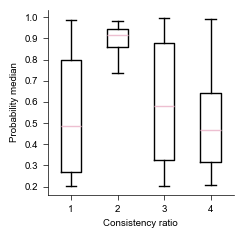

In [14]:
import matplotlib.pyplot as plt

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

data = list(c_to_medians.values())

plt.figure(figsize=(2.4, 2.4))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.boxplot(data, tick_labels=c_to_medians.keys(), showfliers=False)
plt.xlabel("Consistency ratio")
plt.ylabel("Probability median")

# plt.savefig(fig_file, bbox_inches="tight", transparent=True)